Dữ liệu được lấy trên nền tảng kaggle, đường dẫn là https://www.kaggle.com/datasets/shree1992/housedata

In [ ]:
import numpy as np 
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [363]:
data = pd.read_csv('/kaggle/input/housedata/data.csv')
data.head(2)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.5,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA


In [364]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [365]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

# Xem xét các features nào có thể đưa vào mô hình để train

In [366]:
object_cols = data.select_dtypes(include='object').columns
print(object_cols)

Index(['date', 'street', 'city', 'statezip', 'country'], dtype='object')


In [367]:
data['city'].nunique()

44

In [368]:
data['country'].nunique() 

1

In [369]:
data['street'].nunique()

4525

In [370]:
data['statezip'].nunique()

77

- Feature city có thể sử dụng làm dữ liệu vì số lượng city chưa lớn quá mức để bùng nổ dữ liệu
- Vì feature country có 1 nước duy nhất nên có thể drop
- Feature street có số categories quá nhiều
- Vỉ tất country có 1 nước duy nhất là USA nên sẽ bỏ qua statezip

In [371]:
data = data.drop(['street', 'statezip', 'country'], axis=1)
data.head(1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline


# Biến đổi chuỗi thời gian
Biến đổi chuỗi thành các ngày, tháng, năm cho model có thể học hiệu quả

In [372]:
data['date'] = pd.to_datetime(data['date'], errors='coerce')

In [373]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['dayofweek'] = data['date'].dt.dayofweek
data = data.drop('date', axis=1)

In [374]:
data.head(4)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,year,month,dayofweek
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5,4
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,2014,5,4
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,2014,5,4
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,2014,5,4


In [375]:
X = data.drop('price', axis=1)  
y = data['price']             

In [376]:
from sklearn.model_selection import train_test_split
# Tách dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   
    random_state=42,    
    shuffle=True        
)

# Xử lý các kiểu dữ liệu không phải số

In [377]:
object_cols = data.select_dtypes(include='object').columns
print(object_cols)

Index(['city'], dtype='object')


In [378]:

from sklearn.preprocessing import OneHotEncoder

# 1. One-hot encode city
encoder_city = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_encoded = encoder_city.fit_transform(X_train[['city']])
test_encoded = encoder_city.transform(X_test[['city']])

city_encoded_cols = encoder_city.get_feature_names_out(['city'])

train_city_df = pd.DataFrame(train_encoded, columns=city_encoded_cols, index=X_train.index)
test_city_df = pd.DataFrame(test_encoded, columns=city_encoded_cols, index=X_test.index)

X_train = pd.concat([X_train.drop('city', axis=1), train_city_df], axis=1)
X_test = pd.concat([X_test.drop('city', axis=1), test_city_df], axis=1)


In [379]:
X_train.head(4)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
1898,4.0,2.50,2770,45514,2.0,0,0,4,2770,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1370,4.0,3.00,3720,29043,2.0,0,0,3,3720,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3038,4.0,2.50,2810,11120,2.0,0,0,3,2810,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2361,4.0,3.75,4030,10800,2.0,0,0,3,4030,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Xử lý outlier

In [380]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
mask = (y_train >= Q1 - 1.5 * IQR) & (y_train <= Q3 + 1.5 * IQR)

X_train = X_train[mask]
y_train = y_train[mask]

# Xây dựng baseline model
Xây dựng model xử lý dữ liệu thô để so sánh với các model qua các bước feature engineering xem xử lý có hiệu quả không.

In [381]:
from sklearn import linear_model
baseline = linear_model.LinearRegression()
baseline.fit(X_train, y_train)

LinearRegression()

# Dự đoán giá nhà và đánh giá mô hình baseline

In [382]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = baseline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R^2 Score: {r2}")


MSE: 982308223131.6874
MAE: 170238.84293908585
R^2 Score: 0.036807620402958596


In [383]:
def plot(y_test, y_pred):
    sns.set(style="whitegrid")
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Giá thực tế")
    plt.ylabel("Giá dự đoán")
    plt.title("Giá thực tế vs Giá dự đoán (Linear Regression)")
    plt.show()
    
def residual_plot(y_test, y_pred):
    residuals = y_test - y_pred
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Giá dự đoán")
    plt.ylabel("Sai số (Residuals)")
    plt.title("Residual Plot")
    plt.show()


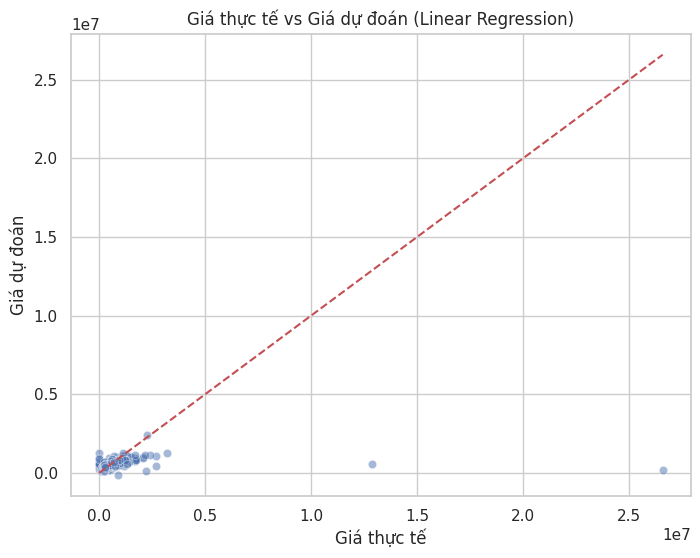

In [384]:
plot(y_test, y_pred)

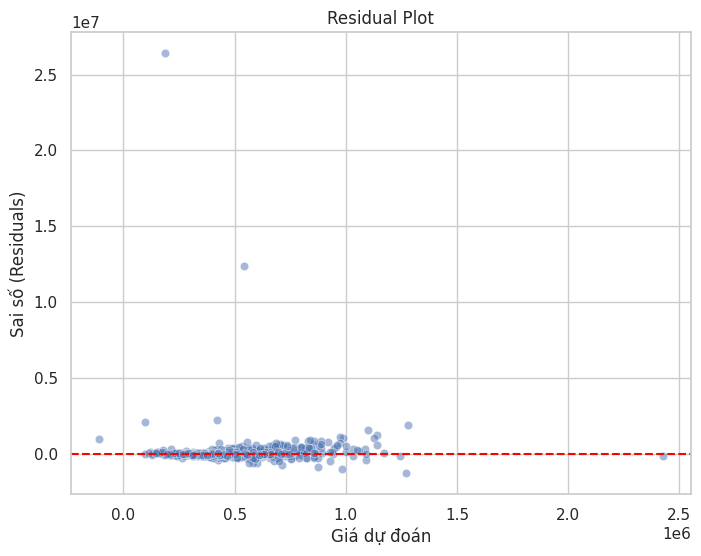

In [385]:
residual_plot(y_test, y_pred)

# Xử lý các feature của dữ liệu và xây dựng mô hình mới

In [386]:
data = pd.read_csv('/kaggle/input/housedata/data.csv')

In [387]:
data_len = len(data)

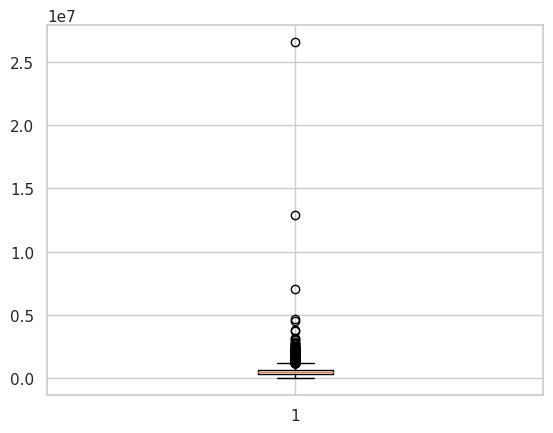

In [388]:
import matplotlib.pyplot as plt
plt.boxplot(data['price'])
plt.show()

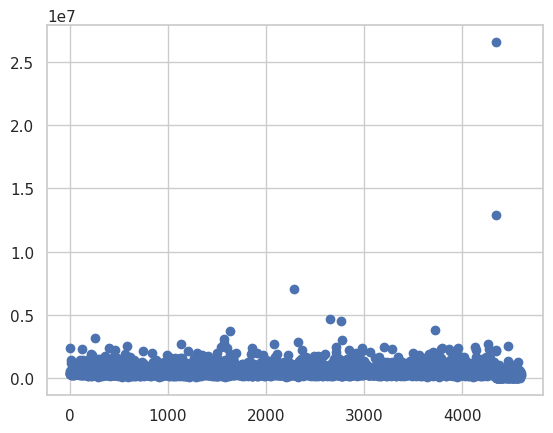

In [389]:
plt.scatter(range(len(data['price'])), data['price'])
plt.show()

## Xử lý outlier trong dữ liệu

In [390]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(data['price']))
data = data[z_scores < 3]  

In [391]:
data_len_remove_outlier = len(data)

In [392]:
ratito_remove = (data_len - data_len_remove_outlier) / data_len
number_remove = data_len - data_len_remove_outlier

print(ratito_remove, "%")
print(number_remove)

0.007391304347826087 %
34


## Drop các column không cần thiết

In [393]:
data = data.drop(['street', 'statezip', 'country'], axis=1)

## Xử lý chuỗi thời gian

In [394]:
data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['dayofweek'] = data['date'].dt.dayofweek
data = data.drop('date', axis=1)

In [395]:
data.head(2)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,year,month,dayofweek
0,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5,4
2,342000.0,3.0,2.0,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,2014,5,4


## Tạo các feature mới

In [396]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,year,month,dayofweek
count,4.566000e+03,4566.000000,4566.000000,4566.000000,4.566000e+03,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.0,4566.000000,4566.000000
mean,5.272448e+05,3.393123,2.147668,2115.666010,1.477236e+04,1.509746,0.005694,0.229085,3.450942,1810.408673,305.257337,1970.787560,809.375164,2014.0,5.756242,2.003066
std,3.053655e+05,0.903364,0.762967,903.268039,3.574062e+04,0.537797,0.075253,0.757348,0.676067,830.905298,448.625012,29.699517,979.550405,0.0,0.683028,1.455131
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,2014.0,5.000000,0.000000
25%,3.202500e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,2014.0,5.000000,1.000000
50%,4.599950e+05,3.000000,2.250000,1970.000000,7.663000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,2014.0,6.000000,2.000000
75%,6.500000e+05,4.000000,2.500000,2600.000000,1.092000e+04,2.000000,0.000000,0.000000,4.000000,2290.000000,600.000000,1997.000000,1999.000000,2014.0,6.000000,3.000000
max,2.238888e+06,9.000000,6.500000,8020.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,8020.000000,2850.000000,2014.000000,2014.000000,2014.0,7.000000,6.000000


- Từ dữ liệu này có thể thấy, yr_renovated biến động khá lớn và không hợp lệ để train vì nếu chưa được sửa thì nó bằng 0 còn sửa rồi thì nó là năm đó, nên ta thêm thuộc tính renovated để xem nó có sửa hay chưa.
- Dữ liệu về year cũng chỉ có 1 năm duy nhất là 2014 nên có thể bỏ qua
- Feature yt_build cũng đã được chuẩn hóa sang age nên có thể bỏ qua

Thêm tuối của ngôi nhà tại thời điểm bán

In [397]:
data['age'] = data['year'] - data['yr_built']
data.head(1)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,year,month,dayofweek,age
0,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5,4,59


Tạo thêm feature renovated

In [398]:
# Nếu chưa renovate (yr_renovated = 0), set since_renovated = 0
data['renovated'] = np.where(data['yr_renovated'] == 0, 0, 1)

In [399]:
data.head(4)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,year,month,dayofweek,age,renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5,4,59,1
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,2014,5,4,48,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,2014,5,4,51,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,2014,5,4,38,1


## Chuẩn hóa các kiểu dữ liệu số

In [400]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,year,month,dayofweek,age,renovated
count,4.566000e+03,4566.000000,4566.000000,4566.000000,4.566000e+03,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.0,4566.000000,4566.000000,4566.000000,4566.000000
mean,5.272448e+05,3.393123,2.147668,2115.666010,1.477236e+04,1.509746,0.005694,0.229085,3.450942,1810.408673,305.257337,1970.787560,809.375164,2014.0,5.756242,2.003066,43.212440,0.405826
std,3.053655e+05,0.903364,0.762967,903.268039,3.574062e+04,0.537797,0.075253,0.757348,0.676067,830.905298,448.625012,29.699517,979.550405,0.0,0.683028,1.455131,29.699517,0.491105
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,2014.0,5.000000,0.000000,0.000000,0.000000
25%,3.202500e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,2014.0,5.000000,1.000000,17.000000,0.000000
50%,4.599950e+05,3.000000,2.250000,1970.000000,7.663000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,2014.0,6.000000,2.000000,38.000000,0.000000
75%,6.500000e+05,4.000000,2.500000,2600.000000,1.092000e+04,2.000000,0.000000,0.000000,4.000000,2290.000000,600.000000,1997.000000,1999.000000,2014.0,6.000000,3.000000,63.000000,1.000000
max,2.238888e+06,9.000000,6.500000,8020.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,8020.000000,2850.000000,2014.000000,2014.000000,2014.0,7.000000,6.000000,114.000000,1.000000


In [401]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4566 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4566 non-null   float64
 1   bedrooms       4566 non-null   float64
 2   bathrooms      4566 non-null   float64
 3   sqft_living    4566 non-null   int64  
 4   sqft_lot       4566 non-null   int64  
 5   floors         4566 non-null   float64
 6   waterfront     4566 non-null   int64  
 7   view           4566 non-null   int64  
 8   condition      4566 non-null   int64  
 9   sqft_above     4566 non-null   int64  
 10  sqft_basement  4566 non-null   int64  
 11  yr_built       4566 non-null   int64  
 12  yr_renovated   4566 non-null   int64  
 13  city           4566 non-null   object 
 14  year           4566 non-null   int32  
 15  month          4566 non-null   int32  
 16  dayofweek      4566 non-null   int32  
 17  age            4566 non-null   int64  
 18  renovated    

In [402]:
numeric_features = ['sqft_living', 'sqft_lot',
                    'sqft_above', 'sqft_basement', 'age'
                   ]
data[numeric_features] = data[numeric_features].apply(lambda x: np.log1p(x))  # log-transform numeric

In [403]:
data.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'year', 'month', 'dayofweek', 'age',
       'renovated'],
      dtype='object')

In [404]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,year,month,dayofweek,age,renovated
count,4.566000e+03,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.0,4566.000000,4566.000000,4566.000000,4566.000000
mean,5.272448e+05,3.393123,2.147668,7.570223,8.997610,1.509746,0.005694,0.229085,3.450942,7.407361,2.593444,1970.787560,809.375164,2014.0,5.756242,2.003066,3.448170,0.405826
std,3.053655e+05,0.903364,0.762967,0.422211,0.909452,0.537797,0.075253,0.757348,0.676067,0.429982,3.198590,29.699517,979.550405,0.0,0.683028,1.455131,0.981818,0.491105
min,0.000000e+00,0.000000,0.000000,5.916202,6.459904,1.000000,0.000000,0.000000,1.000000,5.916202,0.000000,1900.000000,0.000000,2014.0,5.000000,0.000000,0.000000,0.000000
25%,3.202500e+05,3.000000,1.750000,7.286876,8.517393,1.000000,0.000000,0.000000,3.000000,7.082549,0.000000,1951.000000,0.000000,2014.0,5.000000,1.000000,2.890372,0.000000
50%,4.599950e+05,3.000000,2.250000,7.586296,8.944289,1.500000,0.000000,0.000000,3.000000,7.372118,0.000000,1976.000000,0.000000,2014.0,6.000000,2.000000,3.663562,0.000000
75%,6.500000e+05,4.000000,2.500000,7.863651,9.298443,2.000000,0.000000,0.000000,4.000000,7.736744,6.398595,1997.000000,1999.000000,2014.0,6.000000,3.000000,4.158883,1.000000
max,2.238888e+06,9.000000,6.500000,8.989818,13.887104,3.500000,1.000000,4.000000,5.000000,8.989818,7.955425,2014.000000,2014.000000,2014.0,7.000000,6.000000,4.744932,1.000000


In [405]:
columns_train = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'city', 'month', 'dayofweek', 'age', 'renovated']

X = data[columns_train]
y = data['price']     

In [406]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   
    random_state=42,    
    shuffle=True        
)

In [407]:
from sklearn.preprocessing import OneHotEncoder

# 1. One-hot encode city
encoder_city = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_encoded = encoder_city.fit_transform(X_train[['city']])
test_encoded = encoder_city.transform(X_test[['city']])

city_encoded_cols = encoder_city.get_feature_names_out(['city'])

train_city_df = pd.DataFrame(train_encoded, columns=city_encoded_cols, index=X_train.index)
test_city_df = pd.DataFrame(test_encoded, columns=city_encoded_cols, index=X_test.index)

X_train = pd.concat([X_train.drop('city', axis=1), train_city_df], axis=1)
X_test = pd.concat([X_test.drop('city', axis=1), test_city_df], axis=1)


In [408]:
from sklearn import linear_model
baseline = linear_model.LinearRegression()

baseline.fit(X_train, y_train)

LinearRegression()

In [409]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = baseline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R^2 Score: {r2}")


MSE: 33547318918.78694
MAE: 116802.45547773378
R^2 Score: 0.5892755335856208


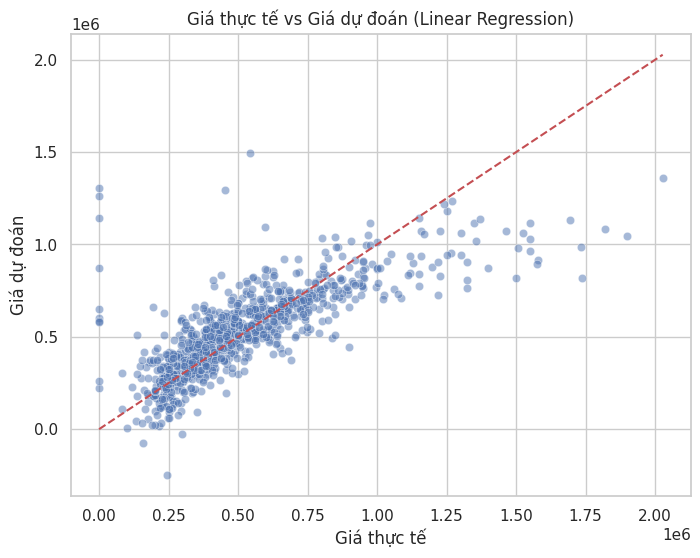

In [410]:
plot(y_test, y_pred)

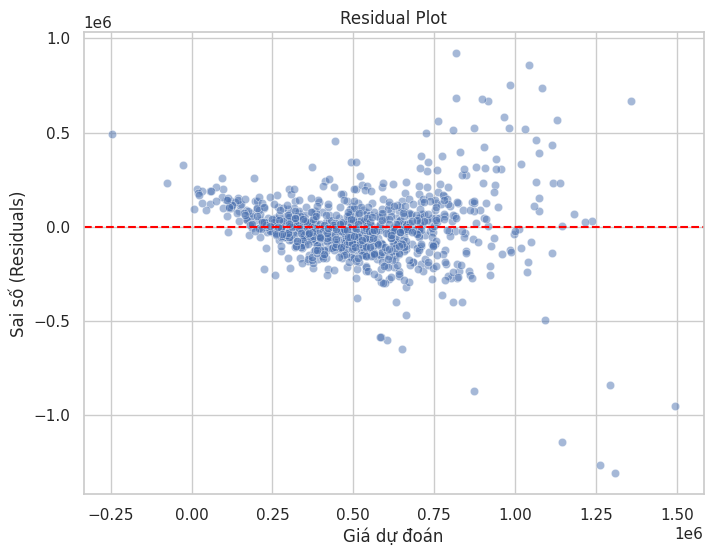

In [411]:
residual_plot(y_test, y_pred)